# 多因子选股 · 机器学习分类模型开发样例（优化版 v2）

> **面向背景**：金融量化交易 · 多因子选股 · A 股（红涨绿跌配色）
> **数据**：`model_data_stock.csv`（面板数据：股票 × 季度报告期，17 个因子 + 二分类标签 Y）
> **目标**：从 **数据清洗 → 特征工程 → 多模型训练 → 样本外评价 → 简易分层回测** 走通一套完整流程，
> 系统演示逻辑回归、决策树、随机森林、XGBoost、KNN、SVM、朴素贝叶斯等分类模型在选股场景的应用，并用量化视角解读结果。

> ⚠️ **默认假设**（如与你的实际设定不符，请相应修改）：
> 1. **标签 Y 编码**：`TRUE → 1`，`FALSE → 0`（正例 = 下期表现好的股票，具体业务定义以你为准）。
> 2. **模型集（每个模型单独成章）**：逻辑回归 LR / 决策树 DT / 随机森林 RF / K近邻 KNN / 支持向量机 SVM / 朴素贝叶斯 NB / **XGBoost**；
>    梯度提升家族**仅保留 XGBoost**（已移除 GBDT、LightGBM），且 XGBoost 已在 arm64 环境成功启用。
> 3. **数据切分**：严格按时间（报告期）切分——前 3 期训练 / 第 4 期验证 / 第 5 期**样本外**测试（**禁止随机切分**，否则未来信息泄露）。
> 4. **中性化**：基础教学版，未做行业 / 市值中性化，文末给出扩展方向。


## 第 0 部分 · 环境与配置

导入所需库，设置随机种子、A 股红涨绿跌配色与中文显示。

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, average_precision_score)
from sklearn.inspection import permutation_importance

%matplotlib inline
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# A股配色：红涨绿跌
COLOR_UP = '#d62728'     # 红（上涨/正例）
COLOR_DOWN = '#2ca02c'   # 绿（下跌/负例）
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti SC', 'PingFang SC', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
print('环境就绪 ✅')

环境就绪 ✅


## 第 1 部分 · 数据加载与认识（EDA）

注意：原始表头含一个带逗号的中文列（`市盈率PE(TTM,扣除非经常性损益)`），用引号包裹，pandas 会正确解析为单列。
我们用**位置映射**把它和其余因子统一改成英文短名，避免后续报错的麻烦。

**标签 Y 编码约定**：`TRUE → 1`，`FALSE → 0`（下面代码显式映射并打印确认）。

In [2]:
DATA_PATH = 'model_data_stock.csv'   # 与 notebook 同目录

RENAME = {
    'Date': 'Date', 'Code': 'Code', 'Y': 'Y',
    '企业倍数(EV除EBITDA)': 'EV_EBITDA',
    '市净率PB(MRQ)': 'PB',
    '市现率PCF(现金净流量TTM)': 'PCF_cash',
    '市现率PCF(经营现金流TTM)': 'PCF_oper',
    '市盈率PE(TTM)': 'PE',
    '市盈率PE(TTM,扣除非经常性损益)': 'PE_ex',
    '市销率PS(TTM)': 'PS',
    '股息率(近12个月)': 'DIV',
    'MV': 'MV',
    '净利润同比增长率': 'G_profit',
    '净资产同比增长率': 'G_equity',
    '利润总额(同比增长率)': 'G_totalprofit',
    '基本每股收益(同比增长率)': 'G_eps',
    '总资产同比增长率': 'G_assets',
    '现金净流量同比增长率': 'G_cashflow',
    '营业利润(同比增长率)': 'G_opprofit',
    '营业总收入(同比增长率)': 'G_revenue',
}
FEATURES = [v for k, v in RENAME.items() if k not in ('Date', 'Code', 'Y')]

df = pd.read_csv(DATA_PATH)
df = df.rename(columns=RENAME)
df['Date'] = pd.to_datetime(df['Date'])

# 标签编码：TRUE/1 -> 1, FALSE/0 -> 0（显式确认 Y 的取值定义）
print('Y 原始取值样例:', df['Y'].unique()[:5])
df['Y'] = df['Y'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0, 1: 1, 0: 0}).astype(int)
print('Y 编码后取值 :', sorted(df['Y'].unique()), '  (TRUE=1, FALSE=0)')

print('\n数据形状 :', df.shape)
print('特征数   :', len(FEATURES))
print('报告期   :', sorted(df['Date'].dt.strftime('%Y-%m-%d').unique()))
print('标签分布 :', dict(df['Y'].value_counts()))
print('股票数   :', df['Code'].nunique())
df[FEATURES].head(3)

Y 原始取值样例: [False  True]
Y 编码后取值 : [np.int64(0), np.int64(1)]   (TRUE=1, FALSE=0)

数据形状 : (20772, 20)
特征数   : 17
报告期   : ['2021-06-30', '2021-09-30', '2021-12-31', '2022-03-31', '2022-06-30']
标签分布 : {0: np.int64(12383), 1: np.int64(8389)}
股票数   : 4281


,EV_EBITDA,PB,PCF_cash,PCF_oper,PE,PE_ex,PS,DIV,MV,G_profit,G_equity,G_totalprofit,G_eps,G_assets,G_cashflow,G_opprofit,G_revenue
0,178.031265,1.450284,4.158766,-9.604662,14.386532,14.418192,2.788759,0.795756,4389.618696,28.549496,7.340985,27.0313,21.212121,13.040136,3.065010,26.9324,8.1095
1,4.087263,1.225560,12.789059,3.788184,6.656121,6.850769,0.637955,4.269690,2698.195472,-13.181867,13.417901,-16.5199,-14.414414,8.241644,-95.340285,-17.2279,14.1862
2,43.451859,2.096619,46.748413,1845.349234,47.051819,48.211020,10.426417,0.680641,30.633767,193.215436,4.885155,93.9522,136.538462,5.093304,-3.498717,92.2387,73.9161


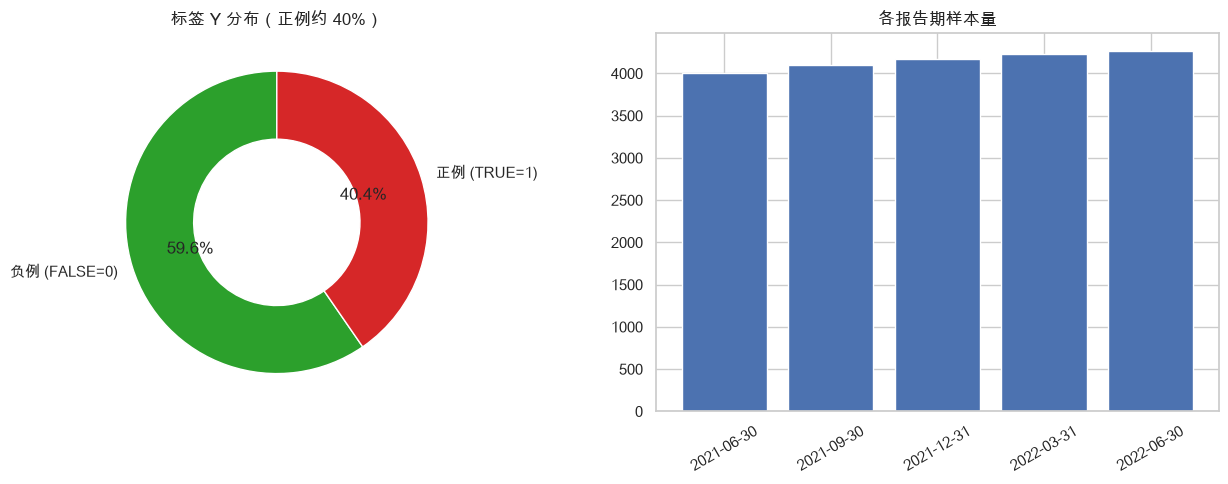

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# 标签分布
vc = df['Y'].value_counts().sort_index()
axes[0].pie(vc.values, labels=['负例 (FALSE=0)', '正例 (TRUE=1)'], autopct='%1.1f%%',
            colors=[COLOR_DOWN, COLOR_UP], startangle=90, wedgeprops=dict(width=0.45))
axes[0].set_title('标签 Y 分布（正例约 {:.0%}）'.format(vc.get(1, 0) / vc.sum()))
# 各报告期样本量
cnt = df.groupby(df['Date'].dt.strftime('%Y-%m-%d')).size()
axes[1].bar(cnt.index, cnt.values, color='#4c72b0')
axes[1].set_title('各报告期样本量')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 1.1 按目标变量 Y 分组的因子均值对比

把样本按 `Y=0`（负例）与 `Y=1`（正例）拆开，比较每个因子的均值差异（标准化后）。
**向右 = 该因子在“好股票”上显著更高，即推高正例概率**——这是逻辑回归系数方向的“数据侧”先验直觉。

,Y=0(负例),Y=1(正例),均值差(标准化)
MV,223.679,180.469,-0.055
G_assets,20.678,18.287,-0.036
PB,5.572,3.519,-0.031
PCF_cash,109.890,-142.919,-0.027
PS,15.941,8.686,-0.010
G_revenue,45.849,34.464,-0.008
G_equity,17.824,17.692,-0.000
G_cashflow,87.582,101.050,0.000
G_profit,4.579,15.718,0.001
PE_ex,15.614,25.510,0.008


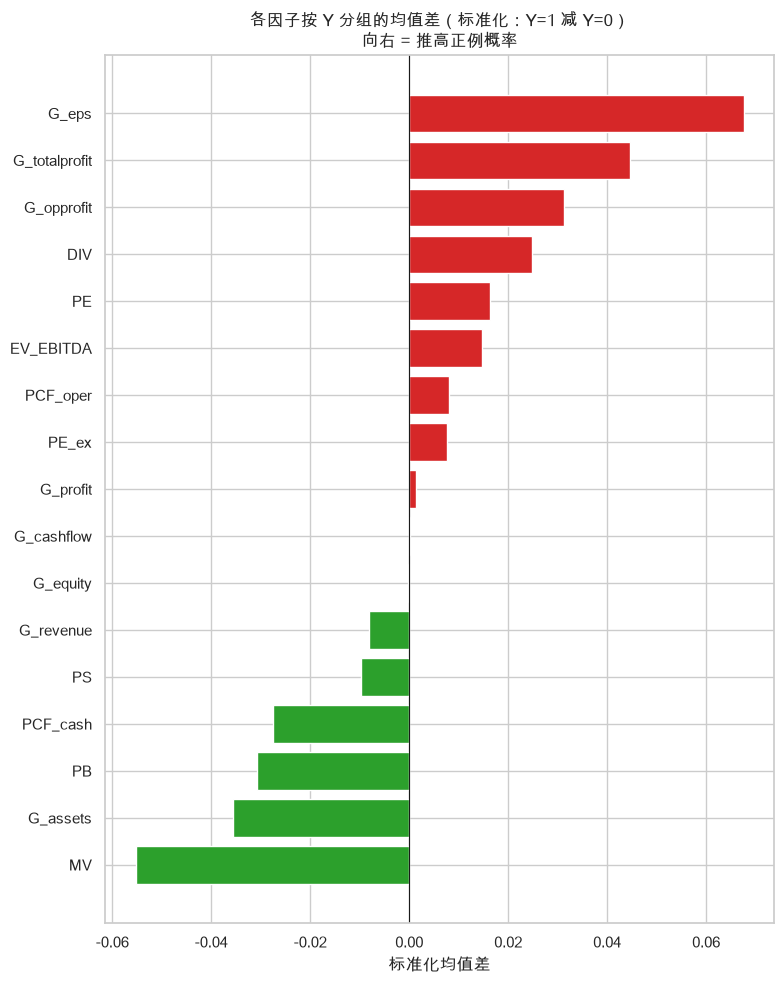

In [4]:
# 按 Y 分组比较各因子均值
mean_by_y = df.groupby('Y')[FEATURES].mean().T
mean_by_y.columns = ['Y=0(负例)', 'Y=1(正例)']
mean_by_y['均值差(标准化)'] = (mean_by_y['Y=1(正例)'] - mean_by_y['Y=0(负例)']) / df[FEATURES].std()
mean_by_y = mean_by_y.sort_values('均值差(标准化)')
display(mean_by_y.round(3))

plt.figure(figsize=(8, 10))
colors = [COLOR_UP if v > 0 else COLOR_DOWN for v in mean_by_y['均值差(标准化)']]
plt.barh(mean_by_y.index, mean_by_y['均值差(标准化)'], color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title('各因子按 Y 分组的均值差（标准化：Y=1 减 Y=0）\n向右 = 推高正例概率')
plt.xlabel('标准化均值差')
plt.tight_layout()
plt.show()

### 1.2 描述性统计 与 特征相关性矩阵（均已包含目标变量 Y）

- **描述性统计**：对 17 个因子 **加上标签 Y** 一并给出均值 / 标准差 / 极值，便于核对 Y 与因子量纲。
- **相关性矩阵**：对「17 因子 + Y」计算 Pearson 相关。**末行 / 末列即为每个因子与 Y 的相关性**，
  一眼看出哪些因子与涨跌标签最相关；同时可发现 PE 与 PE_ex 等强共线（喂给逻辑回归会放大共线性）。

描述性统计（含 Y，节选均值/标准差/极值）:


,mean,std,min,max
EV_EBITDA,73.72,3523.94,-12677.53,321003.80
PB,4.74,66.62,-1214.10,8399.39
PCF_cash,7.79,9210.96,-865178.19,617521.31
PCF_oper,34.31,1167.08,-79641.76,59460.10
PE,-227.63,28697.52,-3176900.50,155726.33
PE_ex,19.61,1282.28,-79457.40,56083.67
PS,13.01,740.89,-7604.11,72003.79
DIV,1.34,1.63,0.01,41.48
MV,206.23,781.33,7.76,25836.22
G_profit,9.08,8776.37,-1009322.12,571255.49


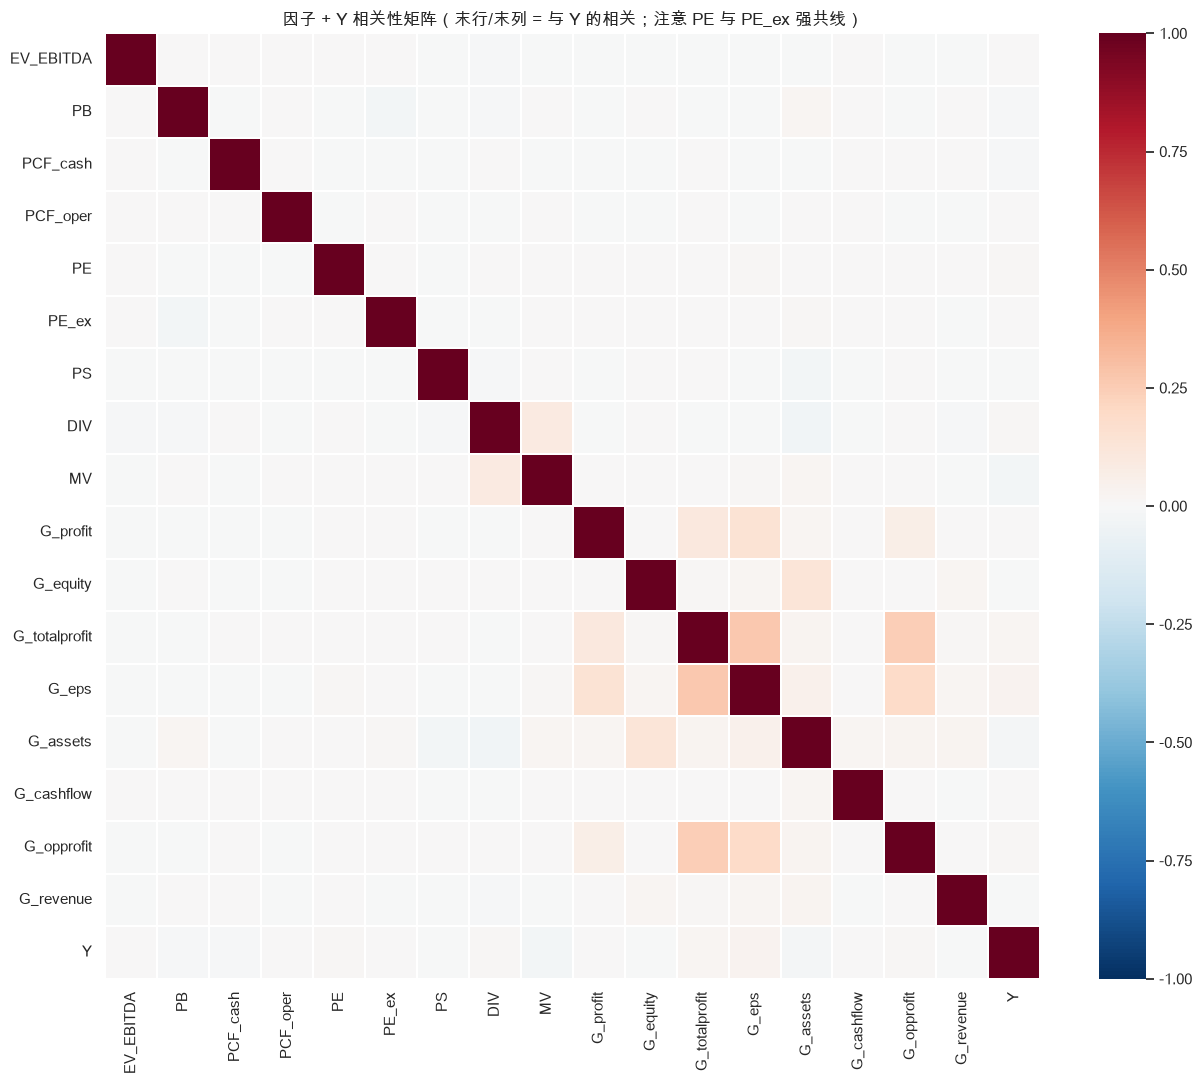

,EV_EBITDA,PB,PCF_cash,PCF_oper,PE,PE_ex,PS,DIV,MV,G_profit,G_equity,G_totalprofit,G_eps,G_assets,G_cashflow,G_opprofit,G_revenue,Y
EV_EBITDA,1.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.01
PB,0.00,1.00,-0.00,0.00,-0.00,-0.03,-0.00,-0.02,0.00,-0.00,0.00,-0.00,-0.01,0.02,0.00,-0.00,0.00,-0.02
PCF_cash,0.00,-0.00,1.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.01
PCF_oper,0.00,0.00,0.00,1.00,-0.00,0.01,-0.00,-0.01,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
PE,0.00,-0.00,-0.00,-0.00,1.00,0.01,-0.00,0.01,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.00,0.01
PE_ex,0.00,-0.03,-0.00,0.01,0.01,1.00,-0.00,-0.01,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,-0.00,0.00
PS,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,1.00,-0.01,0.00,-0.00,0.00,0.00,-0.00,-0.03,-0.00,0.00,-0.00,-0.00
DIV,-0.01,-0.02,0.00,-0.01,0.01,-0.01,-0.01,1.00,0.09,-0.00,0.00,-0.01,-0.01,-0.03,-0.00,0.00,-0.01,0.01
MV,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.09,1.00,0.00,0.00,0.00,0.01,0.02,0.00,0.00,-0.00,-0.03
G_profit,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,1.00,0.00,0.11,0.14,0.02,0.00,0.06,0.00,0.00



各因子与 Y 的 Pearson 相关系数（取自相关性矩阵）:
G_eps            0.033
MV              -0.027
G_totalprofit    0.022
G_assets        -0.017
G_opprofit       0.015
PB              -0.015
PCF_cash        -0.013
DIV              0.012
PE               0.008
EV_EBITDA        0.007
PS              -0.005
G_revenue       -0.004
PCF_oper         0.004
PE_ex            0.004
G_profit         0.001
G_equity        -0.000
G_cashflow       0.000



最强共线因子对（|r| > 0.7）:
Series([], )


In [5]:
# 描述性统计（含目标变量 Y）
print('描述性统计（含 Y，节选均值/标准差/极值）:')
desc = df[FEATURES + ['Y']].describe().T[['mean', 'std', 'min', 'max']]
display(desc.round(2))

# 相关性矩阵（含目标变量 Y）
fig, ax = plt.subplots(figsize=(13, 11))
corr = df[FEATURES + ['Y']].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, vmax=1, vmin=-1,
            annot=False, linewidths=.3, ax=ax)
ax.set_title('因子 + Y 相关性矩阵（末行/末列 = 与 Y 的相关；注意 PE 与 PE_ex 强共线）')
plt.tight_layout()
plt.show()

# 相关系数「数值表」（含目标变量 Y，便于精确读取）
# 末行 / 末列即为各因子与 Y 的相关系数；PE 与 PE_ex 强共线一目了然
display(corr.round(2).style.background_gradient(cmap='RdBu_r', axis=None, vmin=-1, vmax=1)
        .format('{:.2f}')
        .set_caption('因子 + Y 相关系数数值表（末行/末列 = 与 Y 相关；注意 PE 与 PE_ex 强共线）'))

# 打印与 Y 相关性最强 / 最弱的因子（来自矩阵，便于对照 1.3）
corr_y = corr['Y'].drop('Y').sort_values(key=lambda s: s.abs(), ascending=False)
print('\n各因子与 Y 的 Pearson 相关系数（取自相关性矩阵）:')
print(corr_y.round(3).to_string())

# 打印最强共线对（仅因子之间，不含 Y）
feat_corr = df[FEATURES].corr()
pairs = feat_corr.where(~np.eye(len(FEATURES), dtype=bool)).abs().unstack().dropna().sort_values(ascending=False)
pairs = pairs[pairs < 1].drop_duplicates()
print('\n最强共线因子对（|r| > 0.7）:')
print(pairs[pairs > 0.7].head(5).round(3).to_string())

### 1.3 与目标变量 Y 最相关的 Top 特征（箱线图）

取与 Y 相关性绝对值最大的前 10 个因子条形展示，并对 Top 6 画**按 Y 分组的箱线图**，直观看分布差异。

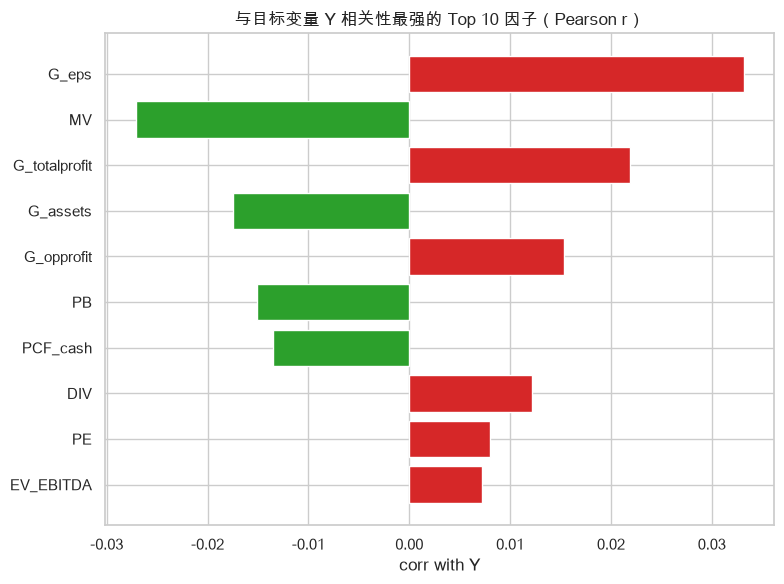

Top 10 因子与 Y 的相关性:
G_eps            0.033
MV              -0.027
G_totalprofit    0.022
G_assets        -0.017
G_opprofit       0.015
PB              -0.015
PCF_cash        -0.013
DIV              0.012
PE               0.008
EV_EBITDA        0.007


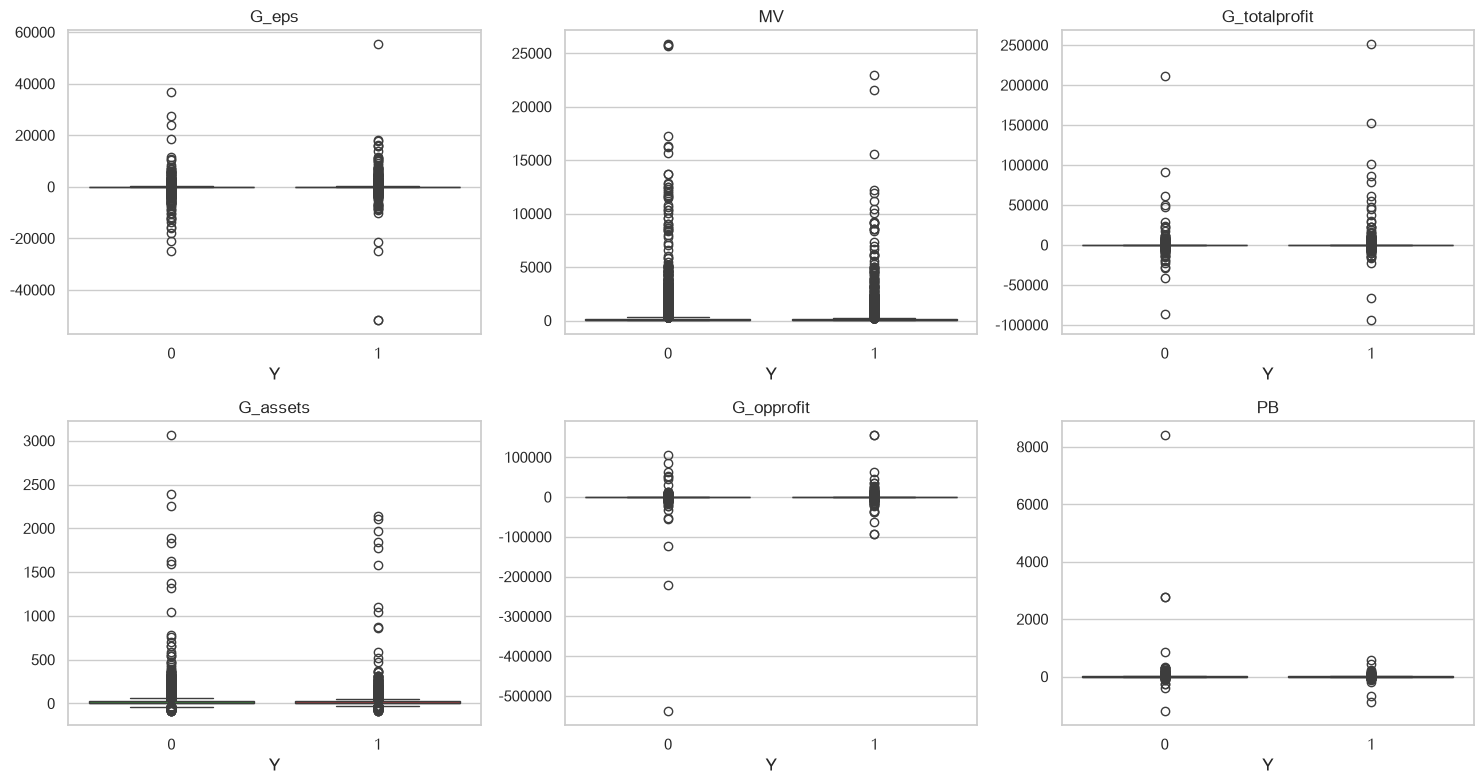

In [6]:
# 与 Y 的相关性，取 Top10
corr_y = df[FEATURES + ['Y']].corr()['Y'].drop('Y')
corr_y = corr_y.sort_values(key=lambda s: s.abs(), ascending=False)
topn = 10
top_corr = corr_y.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > 0 else COLOR_DOWN for v in top_corr.values]
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title('与目标变量 Y 相关性最强的 Top {} 因子（Pearson r）'.format(topn))
plt.xlabel('corr with Y')
plt.tight_layout()
plt.show()
print('Top {} 因子与 Y 的相关性:'.format(topn))
print(top_corr.round(3).to_string())

# Top6 因子按 Y 分组的箱线图
top6 = corr_y.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.ravel(), top6):
    sns.boxplot(y=df[f], x=df['Y'], ax=ax, palette=[COLOR_DOWN, COLOR_UP])
    ax.set_title(f)
    ax.set_xlabel('Y'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 第 2 & 3 部分 · 时间序列切分 + 横截面预处理

> 🚫 **量化命脉：严禁随机切分！** 面板数据有时间维度，随机切分 = 用未来预测过去 = 致命数据泄露。
> 这里按报告期切分：**前 3 期训练 / 第 4 期验证 / 第 5 期样本外测试**。

**预处理原则**：
1. **去极值（Winsorize）**：按报告期分组，对 17 个因子做 1%/99% 分位截尾，处理 PE/PCF 等极端值。
2. **横截面标准化（z-score）**：按报告期分组做——不同时点市场估值水平不同，跨期混合标准化会引入偏差。
3. **关键防泄露**：标准化 / 去极值的参数**只用训练期拟合**，验证 / 测试期直接套用（训练期未见的新日期回退到全局训练参数）。

In [7]:
def fit_cross_section_stats(train_df, features, date_col='Date'):
    # 仅在训练集上拟合：每个报告期分组（回退全局）的去极值边界与 z-score 参数
    stats = {}
    for d, g in train_df.groupby(date_col):
        stats[d] = {
            'lo': g[features].quantile(0.01),
            'hi': g[features].quantile(0.99),
            'mean': g[features].mean(),
            'std': g[features].std().replace(0, 1),
        }
    stats['__global__'] = {
        'lo': train_df[features].quantile(0.01),
        'hi': train_df[features].quantile(0.99),
        'mean': train_df[features].mean(),
        'std': train_df[features].std().replace(0, 1),
    }
    return stats

def apply_cross_section(df, stats, features, date_col='Date'):
    # 应用：按报告期分组去极值 + 标准化；新日期回退全局参数（杜绝未来泄露）
    out = df.copy()
    for d, g in out.groupby(date_col):
        s = stats.get(d, stats['__global__'])
        for f in features:
            out.loc[g.index, f] = out.loc[g.index, f].clip(s['lo'][f], s['hi'][f])
            out.loc[g.index, f] = (out.loc[g.index, f] - s['mean'][f]) / s['std'][f]
    return out

# ===== 时间序列切分 =====
dates_sorted = sorted(df['Date'].unique())
train_dates = dates_sorted[:3]
valid_date  = dates_sorted[3]
test_date   = dates_sorted[4]
print('训练期 :', [d.strftime('%Y-%m-%d') for d in train_dates])
print('验证期 :', valid_date.strftime('%Y-%m-%d'))
print('测试期(样本外) :', test_date.strftime('%Y-%m-%d'))

train_raw = df[df['Date'].isin(train_dates)]
valid_raw = df[df['Date'] == valid_date]
test_raw  = df[df['Date'] == test_date]

# ===== 横截面预处理：仅用训练期拟合，应用到全体 =====
stats = fit_cross_section_stats(train_raw, FEATURES)
train_raw = apply_cross_section(train_raw, stats, FEATURES)
valid_raw = apply_cross_section(valid_raw, stats, FEATURES)
test_raw  = apply_cross_section(test_raw,  stats, FEATURES)

X_train, y_train = train_raw[FEATURES], train_raw['Y']
X_valid, y_valid = valid_raw[FEATURES], valid_raw['Y']
X_test,  y_test  = test_raw[FEATURES],   test_raw['Y']

def pos_ratio(y):
    return '{:.1%}'.format(y.mean())

print('\n集合         样本数   正例比例')
for nm, X, y in [('训练', X_train, y_train), ('验证', X_valid, y_valid), ('测试', X_test, y_test)]:
    print('{:8s}  {:6d}   {}'.format(nm, len(X), pos_ratio(y)))

训练期 : ['2021-06-30', '2021-09-30', '2021-12-31']
验证期 : 2022-03-31
测试期(样本外) : 2022-06-30

集合         样本数   正例比例
训练         12282   46.4%
验证          4228   44.5%
测试          4262   18.9%


## 第 4 部分 · 模型训练（统一接口，逐个建模并存储结果）

统一封装 `train_eval(model, ...)`：训练 → 预测 → 输出概率 → 记录指标（准确率 / 精确率 / 召回率 / F1 / AUC / AP）。
所有模型在**样本外测试集**上评价，结果存入 `results` 字典，供后续「跨模型对比」与「每个模型单独成章」复用。

> 模型集（默认参数 + class_weight 处理 40/60 不平衡）：逻辑回归 LR、决策树 DT、随机森林 RF、K近邻 KNN、支持向量机 SVM、朴素贝叶斯 NB，**仅保留 XGBoost**（梯度提升家族，已移除 GBDT / LightGBM，且已启用）。

In [8]:
from sklearn.base import clone

def train_eval(model, Xtr, ytr, Xte, yte, name):
    # 统一训练-评价接口：返回指标字典与概率
    m = clone(model)
    m.fit(Xtr, ytr)
    y_pred = m.predict(Xte)
    y_proba = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, y_proba)
    prec, rec, _ = precision_recall_curve(yte, y_proba)
    return {
        'name': name, 'model': m,
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': accuracy_score(yte, y_pred),
        'precision': precision_score(yte, y_pred, zero_division=0),
        'recall': recall_score(yte, y_pred, zero_division=0),
        'f1': f1_score(yte, y_pred, zero_division=0),
        'auc': roc_auc_score(yte, y_proba),
        'ap': average_precision_score(yte, y_proba),  # P-R 曲线下面积
        'fpr': fpr, 'tpr': tpr, 'prec_curve': prec, 'rec_curve': rec,
    }

# 模型集合（默认参数 + class_weight 处理 40/60 不平衡）
models = {
    '逻辑回归 LR': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    '决策树 DT': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    '随机森林 RF': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                          random_state=RANDOM_STATE, n_jobs=-1),
    'K近邻 KNN': KNeighborsClassifier(n_neighbors=15),
    '支持向量机 SVM': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    '朴素贝叶斯 NB': GaussianNB(),
}

# XGBoost（梯度提升家族唯一保留项，arm64 环境已启用 libomp）
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                      use_label_encoder=False, eval_metric='logloss',
                                      random_state=RANDOM_STATE, n_jobs=-1)
    print('XGBoost 已加入模型集')
except Exception as e:
    print('XGBoost 未启用，已跳过:', e)

print('\n模型集:', list(models.keys()))

XGBoost 已加入模型集

模型集: ['逻辑回归 LR', '决策树 DT', '随机森林 RF', 'K近邻 KNN', '支持向量机 SVM', '朴素贝叶斯 NB', 'XGBoost']


In [9]:
results = {}
print('在样本外测试集上逐一训练-评价...')
for name, mdl in models.items():
    try:
        results[name] = train_eval(mdl, X_train, y_train, X_test, y_test, name)
        print('  {:14s} AUC={:.3f}  F1={:.3f}'.format(name, results[name]['auc'], results[name]['f1']))
    except Exception as e:
        print('  {:14s} 运行失败: {}'.format(name, e))

print('\n全部完成  共', len(results), '个模型')

在样本外测试集上逐一训练-评价...
  逻辑回归 LR        AUC=0.566  F1=0.325
  决策树 DT         AUC=0.519  F1=0.297


  随机森林 RF        AUC=0.585  F1=0.318
  K近邻 KNN        AUC=0.533  F1=0.307


  支持向量机 SVM      AUC=0.539  F1=0.310
  朴素贝叶斯 NB       AUC=0.506  F1=0.313


  XGBoost        AUC=0.566  F1=0.258

全部完成  共 7 个模型


## 第 5 部分 · 跨模型对比（呼应《模型评价指标手册》）

先把所有模型在**样本外测试集**上的指标汇成一张对比表，并叠加 ROC / P-R 曲线与混淆矩阵网格做横向比较。
**不平衡场景下以 AUC / F1 为准，勿单看 Accuracy**（正例仅约 40%）。

=== 模型测试集表现（按 AUC 降序）===


,准确率,精确率,召回率,F1,AUC,AP(P-R)
模型,,,,,,
随机森林 RF,0.572,0.228,0.527,0.318,0.585,0.243
XGBoost,0.702,0.244,0.274,0.258,0.566,0.247
逻辑回归 LR,0.448,0.212,0.703,0.325,0.566,0.240
支持向量机 SVM,0.400,0.198,0.710,0.310,0.539,0.216
K近邻 KNN,0.450,0.202,0.643,0.307,0.533,0.203
决策树 DT,0.488,0.200,0.570,0.297,0.519,0.203
朴素贝叶斯 NB,0.308,0.193,0.833,0.313,0.506,0.194


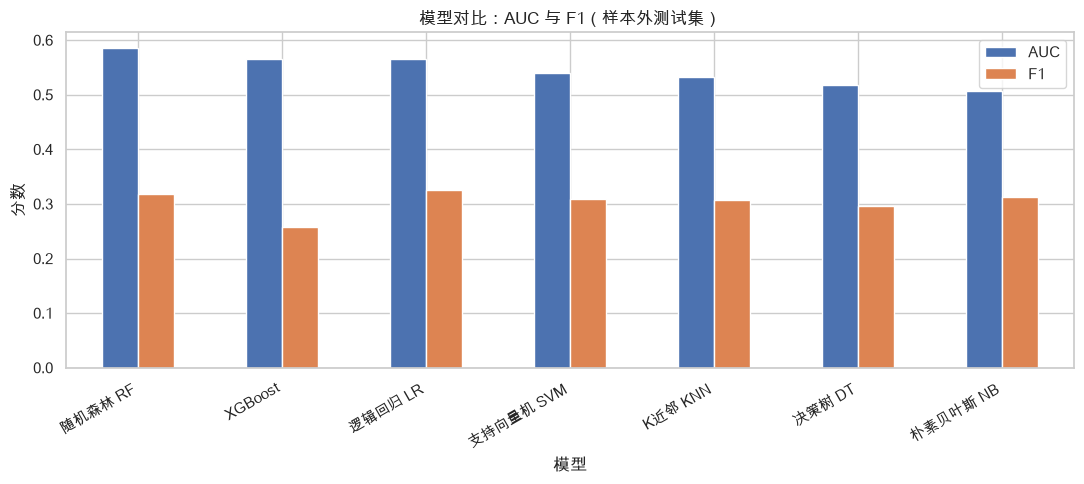

In [10]:
cmp = pd.DataFrame([{
    '模型': r['name'], '准确率': r['accuracy'], '精确率': r['precision'],
    '召回率': r['recall'], 'F1': r['f1'], 'AUC': r['auc'], 'AP(P-R)': r['ap']
} for r in results.values()]).set_index('模型').sort_values('AUC', ascending=False)
print('=== 模型测试集表现（按 AUC 降序）===')
display(cmp.round(3))

# 模型对比柱状图
ax = cmp[['AUC', 'F1']].plot(kind='bar', figsize=(11, 5))
plt.title('模型对比：AUC 与 F1（样本外测试集）')
plt.xticks(rotation=30, ha='right'); plt.ylabel('分数'); plt.legend()
plt.tight_layout(); plt.show()

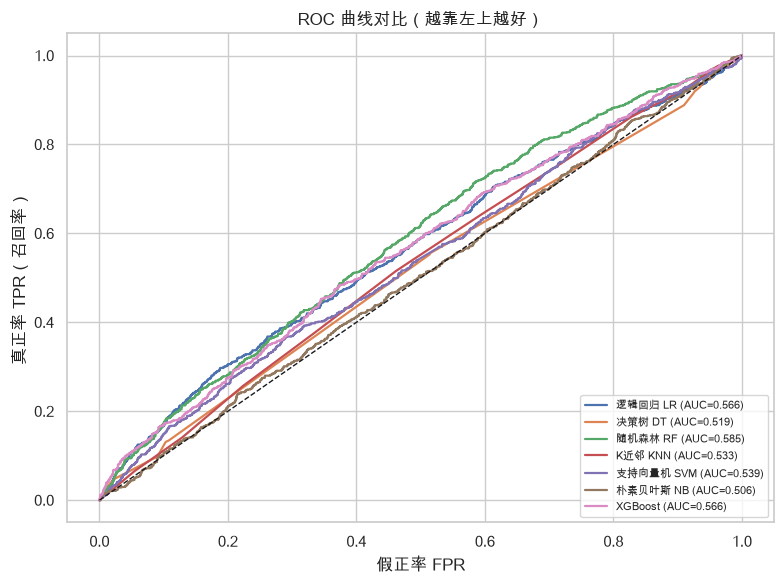

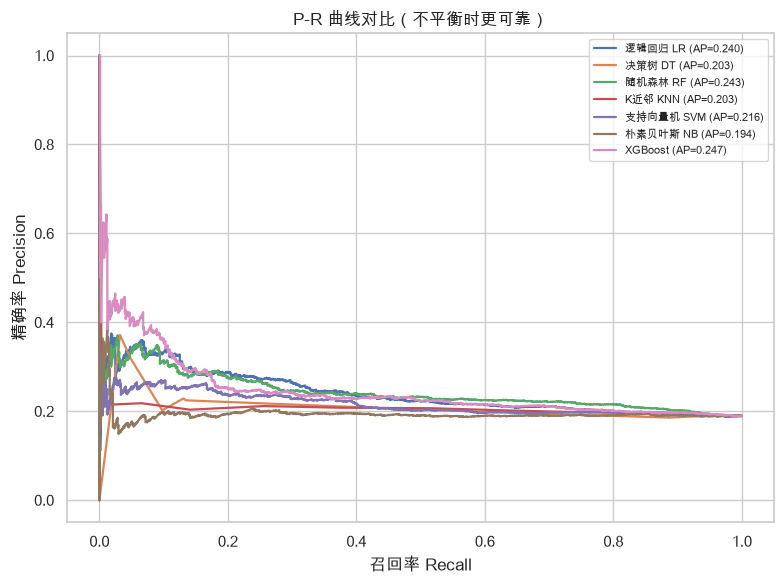

In [11]:
# ROC 对比（每个模型一条曲线）
plt.figure(figsize=(8, 6))
for r in results.values():
    plt.plot(r['fpr'], r['tpr'], lw=1.6, label='{} (AUC={:.3f})'.format(r['name'], r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR')
plt.ylabel('真正率 TPR（召回率）')
plt.title('ROC 曲线对比（越靠左上越好）')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

# P-R 对比（应对不平衡）
plt.figure(figsize=(8, 6))
for r in results.values():
    plt.plot(r['rec_curve'], r['prec_curve'], lw=1.6, label='{} (AP={:.3f})'.format(r['name'], r['ap']))
plt.xlabel('召回率 Recall')
plt.ylabel('精确率 Precision')
plt.title('P-R 曲线对比（不平衡时更可靠）')
plt.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

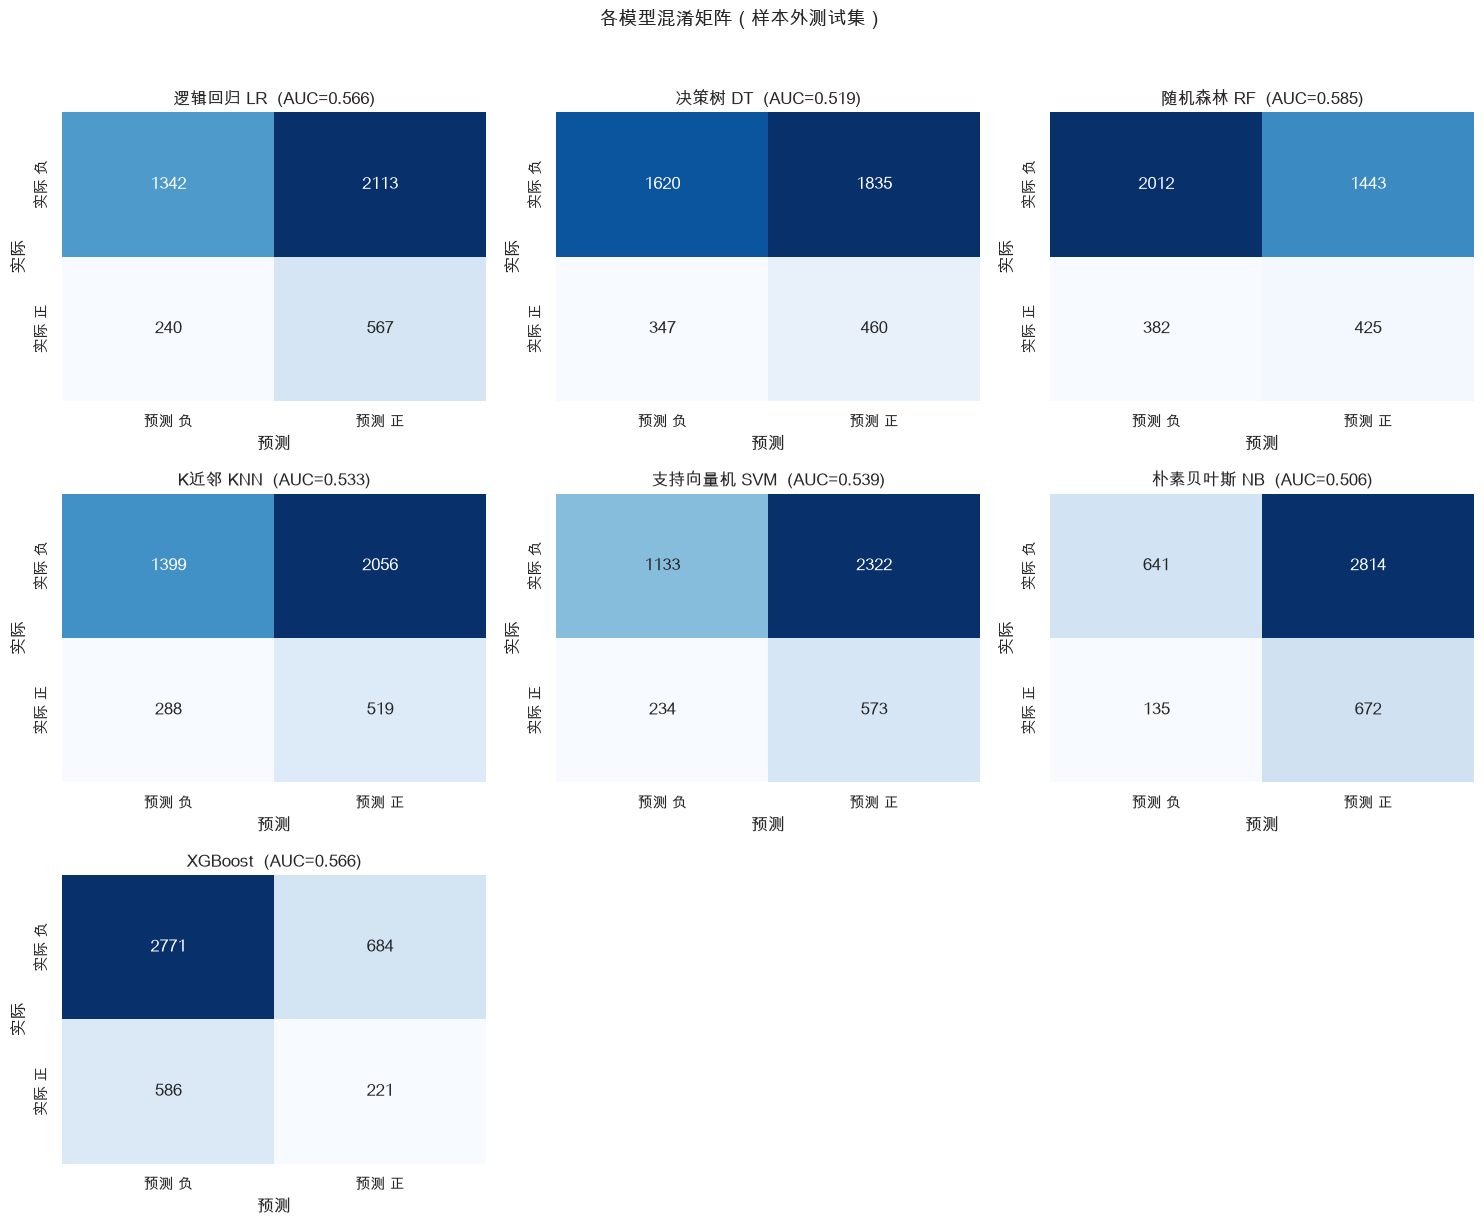

In [12]:
# 各模型混淆矩阵网格（横向对比谁抓得准、谁误报多）
n = len(results)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()
for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['预测 负', '预测 正'],
                yticklabels=['实际 负', '实际 正'], ax=axes[i])
    axes[i].set_title('{}  (AUC={:.3f})'.format(name, r['auc']))
    axes[i].set_xlabel('预测'); axes[i].set_ylabel('实际')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('各模型混淆矩阵（样本外测试集）', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 第 6 ~ 12 部分 · 每个模型单独成章（混淆矩阵 / ROC / AUC / 分析模块）

下面为每个模型各立一章，给出它**自己的**混淆矩阵、ROC 曲线、AUC 及专属分析模块：
- **逻辑回归 LR** → Top 系数（因子方向）
- **决策树 DT / 随机森林 RF / XGBoost** → 特征重要性（树模型原生）
- **KNN / SVM / 朴素贝叶斯** → 排列重要性（permutation importance，黑盒模型的统一可解释性视图）

> 量化提示：结合你更怕「误报（站岗被套，FP）」还是「漏报（踏空，FN）」，在精确率与召回率之间取舍。

## 第 6 章 · 逻辑回归 LR（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **逻辑回归 LR** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=1342    FP=2113  
实际正      FN=240     TP=567   

误报率 FP/(TN+FP) = 61.16%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 29.74%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 21.16%    召回率 = TP/(TP+FN) = 70.26%


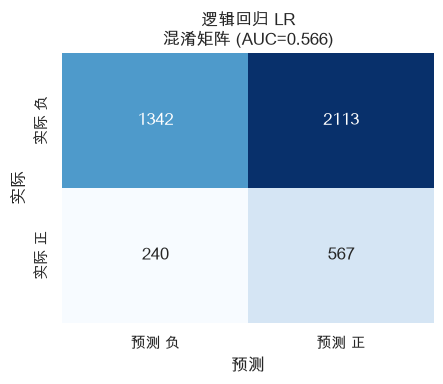

In [13]:

# 逻辑回归 LR · 混淆矩阵（样本外测试集）
r = results['逻辑回归 LR']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('逻辑回归 LR\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


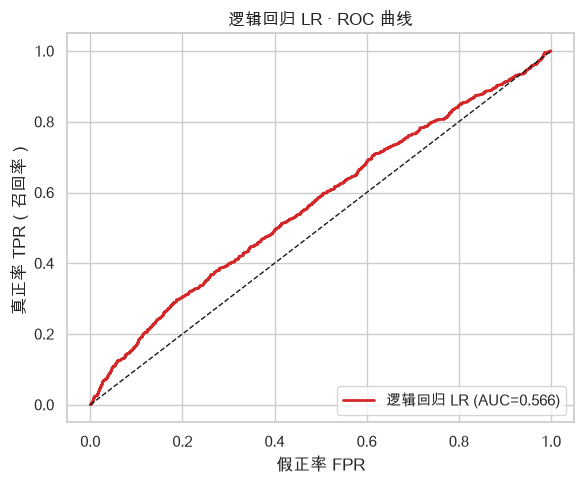

逻辑回归 LR 样本外指标:
  AUC=0.566   AP(P-R)=0.240
  准确率=0.448  精确率=0.212  召回率=0.703  F1=0.325


In [14]:

# 逻辑回归 LR · ROC 曲线与 AUC
r = results['逻辑回归 LR']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='逻辑回归 LR (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('逻辑回归 LR · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('逻辑回归 LR 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


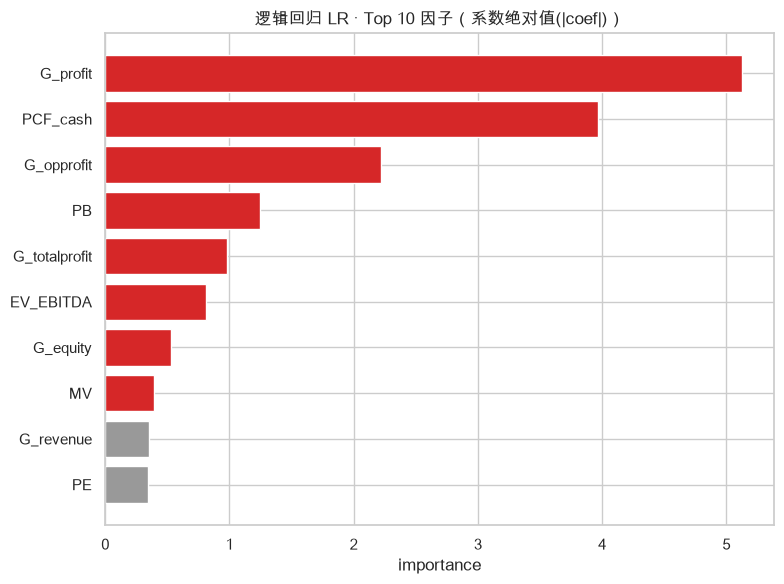

逻辑回归 LR 分析视角: 系数绝对值(|coef|)
最强因子 Top3: ['G_profit', 'PCF_cash', 'G_opprofit']
最弱因子 Bottom3: ['PS', 'G_cashflow', 'DIV']


In [15]:

# 逻辑回归 LR · 分析模块（特征可解释性）
r = results['逻辑回归 LR']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('逻辑回归 LR · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('逻辑回归 LR 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 7 章 · 决策树 DT（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **决策树 DT** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=1620    FP=1835  
实际正      FN=347     TP=460   

误报率 FP/(TN+FP) = 53.11%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 43.00%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 20.04%    召回率 = TP/(TP+FN) = 57.00%


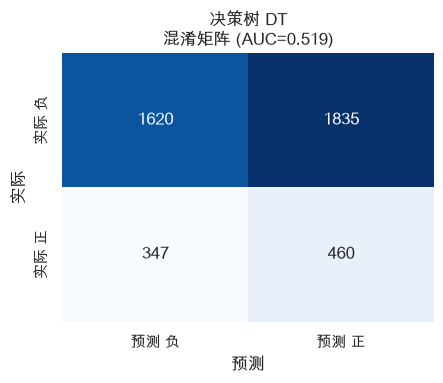

In [16]:

# 决策树 DT · 混淆矩阵（样本外测试集）
r = results['决策树 DT']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('决策树 DT\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


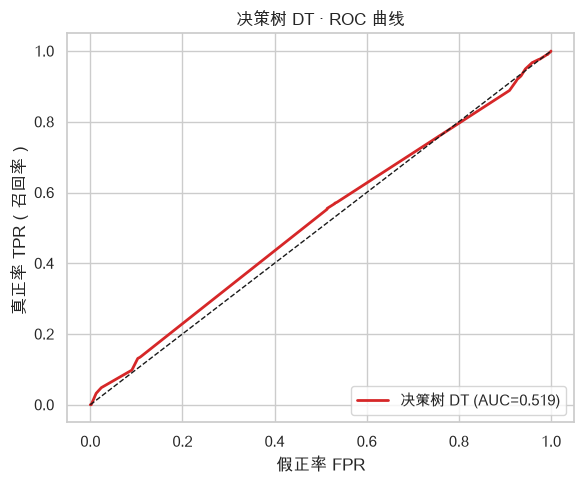

决策树 DT 样本外指标:
  AUC=0.519   AP(P-R)=0.203
  准确率=0.488  精确率=0.200  召回率=0.570  F1=0.297


In [17]:

# 决策树 DT · ROC 曲线与 AUC
r = results['决策树 DT']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='决策树 DT (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('决策树 DT · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('决策树 DT 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


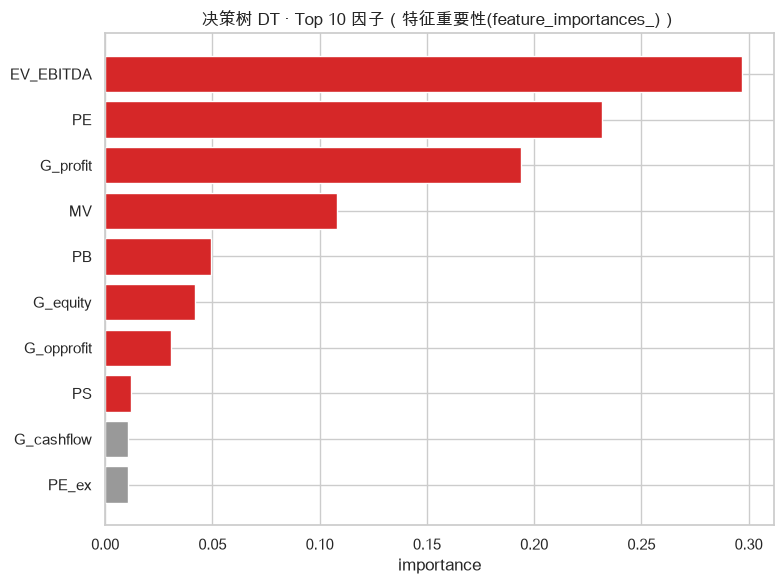

决策树 DT 分析视角: 特征重要性(feature_importances_)
最强因子 Top3: ['EV_EBITDA', 'PE', 'G_profit']
最弱因子 Bottom3: ['G_eps', 'G_assets', 'G_revenue']


In [18]:

# 决策树 DT · 分析模块（特征可解释性）
r = results['决策树 DT']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('决策树 DT · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('决策树 DT 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 8 章 · 随机森林 RF（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **随机森林 RF** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=2012    FP=1443  
实际正      FN=382     TP=425   

误报率 FP/(TN+FP) = 41.77%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 47.34%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 22.75%    召回率 = TP/(TP+FN) = 52.66%


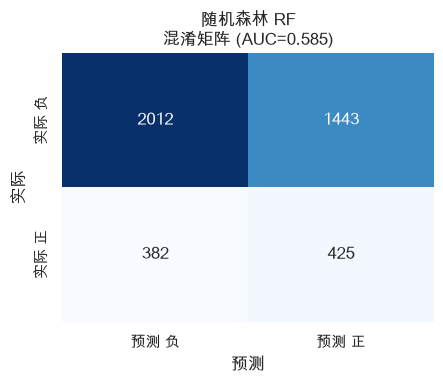

In [19]:

# 随机森林 RF · 混淆矩阵（样本外测试集）
r = results['随机森林 RF']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('随机森林 RF\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


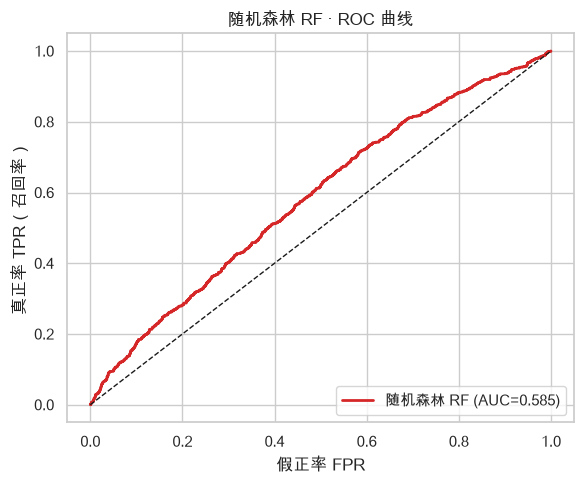

随机森林 RF 样本外指标:
  AUC=0.585   AP(P-R)=0.243
  准确率=0.572  精确率=0.228  召回率=0.527  F1=0.318


In [20]:

# 随机森林 RF · ROC 曲线与 AUC
r = results['随机森林 RF']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='随机森林 RF (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('随机森林 RF · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('随机森林 RF 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


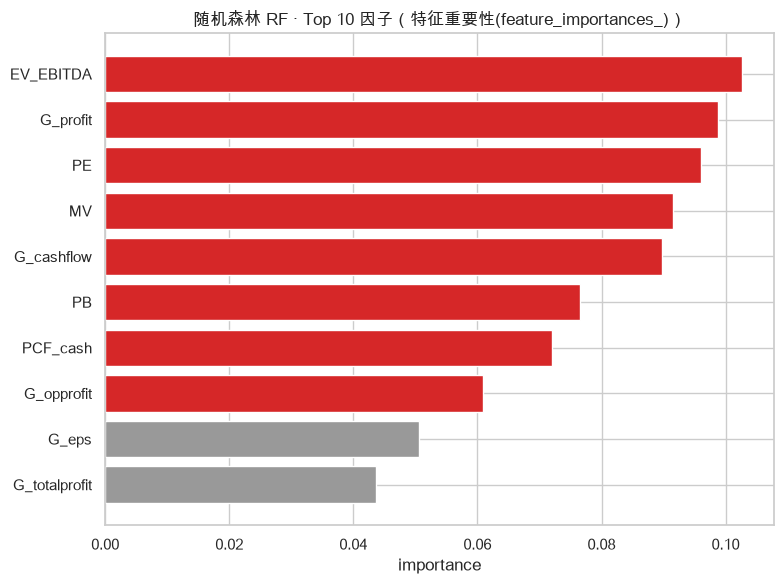

随机森林 RF 分析视角: 特征重要性(feature_importances_)
最强因子 Top3: ['EV_EBITDA', 'G_profit', 'PE']
最弱因子 Bottom3: ['G_assets', 'G_revenue', 'DIV']


In [21]:

# 随机森林 RF · 分析模块（特征可解释性）
r = results['随机森林 RF']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('随机森林 RF · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('随机森林 RF 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 9 章 · K近邻 KNN（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **K近邻 KNN** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=1399    FP=2056  
实际正      FN=288     TP=519   

误报率 FP/(TN+FP) = 59.51%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 35.69%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 20.16%    召回率 = TP/(TP+FN) = 64.31%


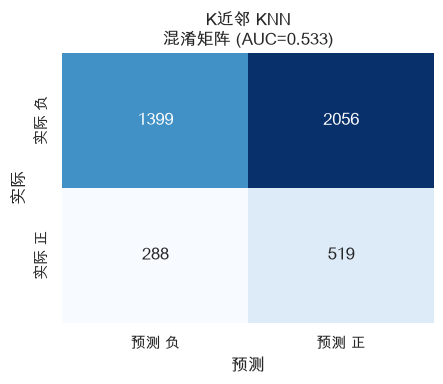

In [22]:

# K近邻 KNN · 混淆矩阵（样本外测试集）
r = results['K近邻 KNN']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('K近邻 KNN\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


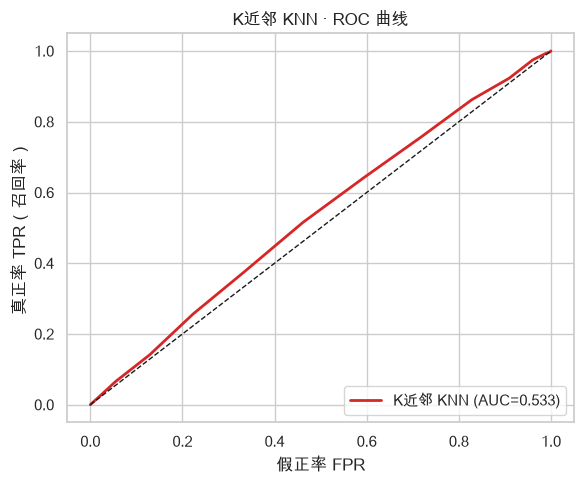

K近邻 KNN 样本外指标:
  AUC=0.533   AP(P-R)=0.203
  准确率=0.450  精确率=0.202  召回率=0.643  F1=0.307


In [23]:

# K近邻 KNN · ROC 曲线与 AUC
r = results['K近邻 KNN']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='K近邻 KNN (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('K近邻 KNN · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('K近邻 KNN 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


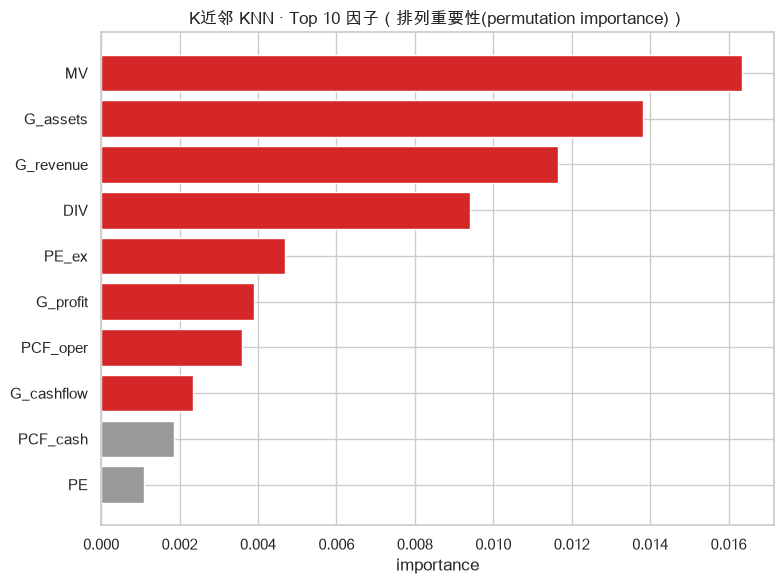

K近邻 KNN 分析视角: 排列重要性(permutation importance)
最强因子 Top3: ['MV', 'G_assets', 'G_revenue']
最弱因子 Bottom3: ['G_eps', 'G_opprofit', 'G_totalprofit']


In [24]:

# K近邻 KNN · 分析模块（特征可解释性）
r = results['K近邻 KNN']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('K近邻 KNN · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('K近邻 KNN 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 10 章 · 支持向量机 SVM（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **支持向量机 SVM** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=1133    FP=2322  
实际正      FN=234     TP=573   

误报率 FP/(TN+FP) = 67.21%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 29.00%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 19.79%    召回率 = TP/(TP+FN) = 71.00%


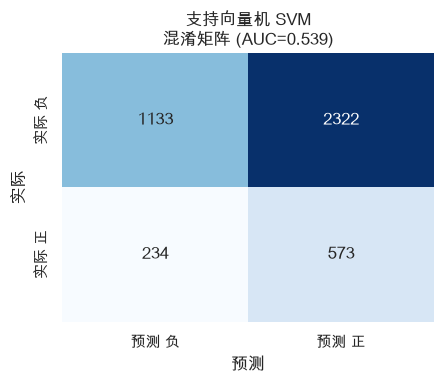

In [25]:

# 支持向量机 SVM · 混淆矩阵（样本外测试集）
r = results['支持向量机 SVM']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('支持向量机 SVM\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


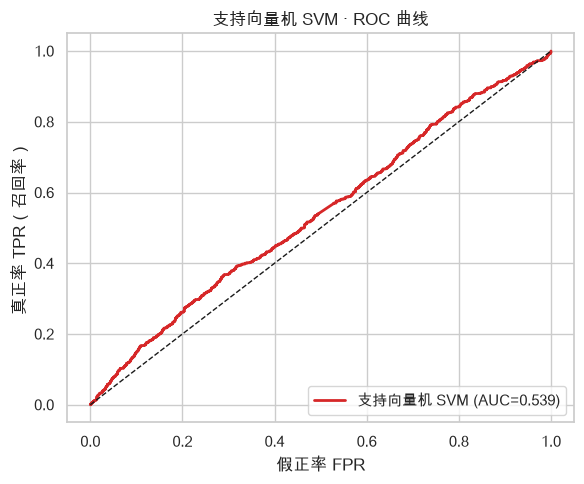

支持向量机 SVM 样本外指标:
  AUC=0.539   AP(P-R)=0.216
  准确率=0.400  精确率=0.198  召回率=0.710  F1=0.310


In [26]:

# 支持向量机 SVM · ROC 曲线与 AUC
r = results['支持向量机 SVM']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='支持向量机 SVM (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('支持向量机 SVM · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('支持向量机 SVM 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


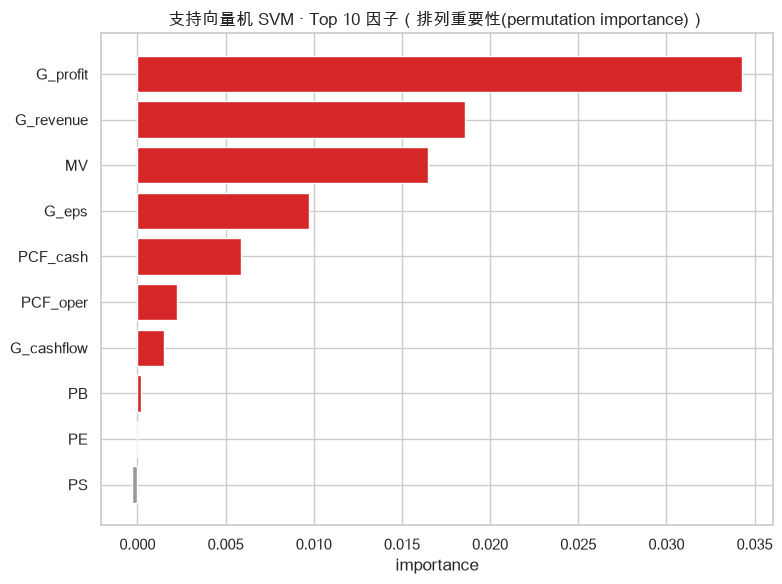

支持向量机 SVM 分析视角: 排列重要性(permutation importance)
最强因子 Top3: ['G_profit', 'G_revenue', 'MV']
最弱因子 Bottom3: ['G_equity', 'G_totalprofit', 'G_opprofit']


In [27]:

# 支持向量机 SVM · 分析模块（特征可解释性）
r = results['支持向量机 SVM']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('支持向量机 SVM · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('支持向量机 SVM 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 11 章 · 朴素贝叶斯 NB（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **朴素贝叶斯 NB** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=641     FP=2814  
实际正      FN=135     TP=672   

误报率 FP/(TN+FP) = 81.45%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 16.73%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 19.28%    召回率 = TP/(TP+FN) = 83.27%


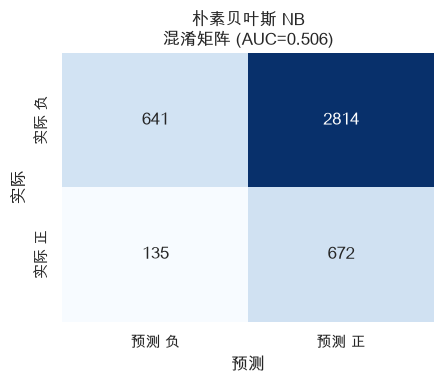

In [28]:

# 朴素贝叶斯 NB · 混淆矩阵（样本外测试集）
r = results['朴素贝叶斯 NB']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('朴素贝叶斯 NB\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


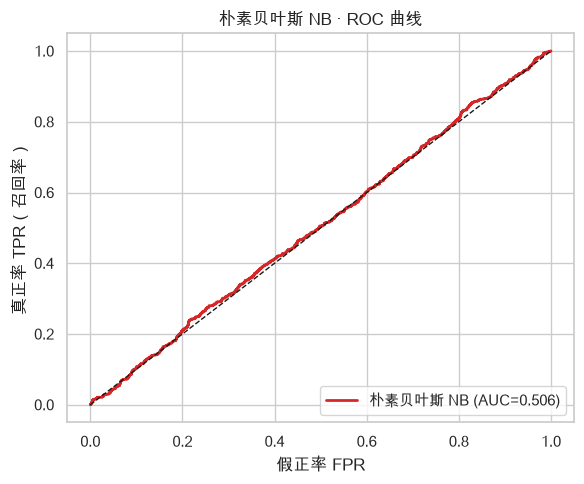

朴素贝叶斯 NB 样本外指标:
  AUC=0.506   AP(P-R)=0.194
  准确率=0.308  精确率=0.193  召回率=0.833  F1=0.313


In [29]:

# 朴素贝叶斯 NB · ROC 曲线与 AUC
r = results['朴素贝叶斯 NB']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='朴素贝叶斯 NB (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('朴素贝叶斯 NB · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('朴素贝叶斯 NB 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


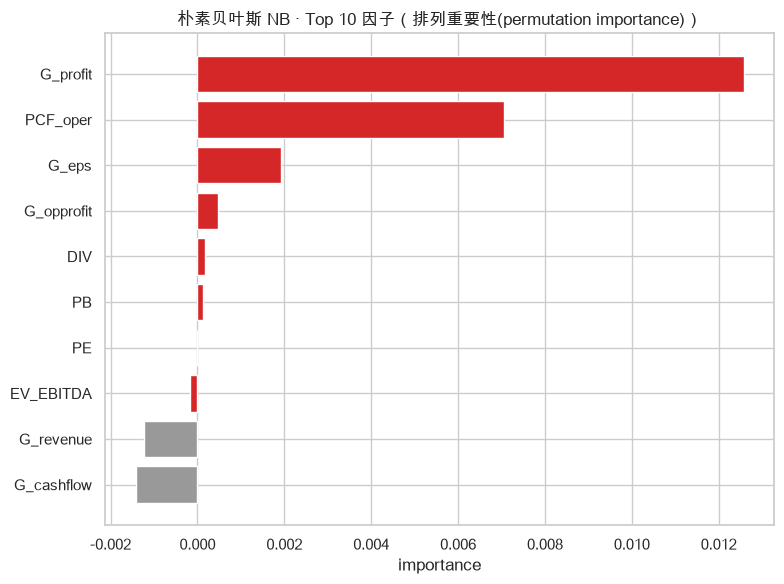

朴素贝叶斯 NB 分析视角: 排列重要性(permutation importance)
最强因子 Top3: ['G_profit', 'PCF_oper', 'G_eps']
最弱因子 Bottom3: ['G_assets', 'PE_ex', 'G_equity']


In [30]:

# 朴素贝叶斯 NB · 分析模块（特征可解释性）
r = results['朴素贝叶斯 NB']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('朴素贝叶斯 NB · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('朴素贝叶斯 NB 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 12 章 · XGBoost（混淆矩阵 / ROC / AUC / 分析模块）

本章针对 **XGBoost** 单独成章，依次给出：
- **混淆矩阵**：TP / TN / FP / FN，并换算误报率、漏报率、精确率、召回率；
- **ROC 曲线与 AUC**：样本外测试集表现；
- **分析模块**：该模型最具代表性的可解释性视图（系数 / 特征重要性 / 排列重要性）。

> 量化提示：若你更怕「误报（站岗被套）」就盯精确率；更怕「漏报（踏空）」就盯召回率。

混淆矩阵（行=实际, 列=预测）
             预测负     预测正
实际负      TN=2771    FP=684   
实际正      FN=586     TP=221   

误报率 FP/(TN+FP) = 19.80%  (把跌看成涨 -> 站岗被套)
漏报率 FN/(TP+FN) = 72.61%  (把涨看成跌 -> 踏空)
精确率 = TP/(TP+FP) = 24.42%    召回率 = TP/(TP+FN) = 27.39%


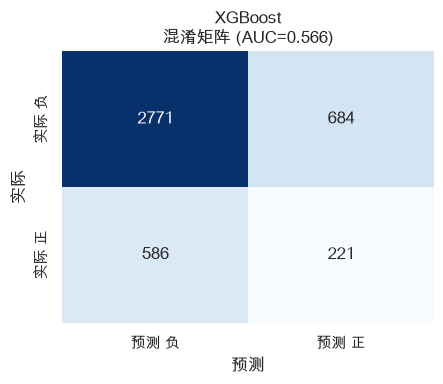

In [31]:

# XGBoost · 混淆矩阵（样本外测试集）
r = results['XGBoost']
cm = confusion_matrix(y_test, r['y_pred'])
tn, fp, fn, tp = cm.ravel()
print('混淆矩阵（行=实际, 列=预测）')
print('             预测负     预测正')
print('实际负      TN={:<6d}  FP={:<6d}'.format(tn, fp))
print('实际正      FN={:<6d}  TP={:<6d}'.format(fn, tp))
print()
print('误报率 FP/(TN+FP) = {:.2%}  (把跌看成涨 -> 站岗被套)'.format(fp/(tn+fp)))
print('漏报率 FN/(TP+FN) = {:.2%}  (把涨看成跌 -> 踏空)'.format(fn/(tp+fn)))
print('精确率 = TP/(TP+FP) = {:.2%}    召回率 = TP/(TP+FN) = {:.2%}'.format(tp/(tp+fp), tp/(tp+fn)))

fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测 负', '预测 正'], yticklabels=['实际 负', '实际 正'], ax=ax)
ax.set_title('XGBoost\n混淆矩阵 (AUC={:.3f})'.format(r['auc']))
ax.set_xlabel('预测'); ax.set_ylabel('实际')
plt.tight_layout(); plt.show()


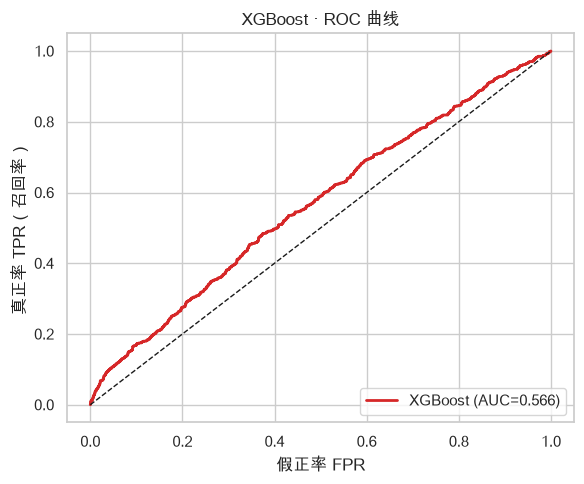

XGBoost 样本外指标:
  AUC=0.566   AP(P-R)=0.247
  准确率=0.702  精确率=0.244  召回率=0.274  F1=0.258


In [32]:

# XGBoost · ROC 曲线与 AUC
r = results['XGBoost']
plt.figure(figsize=(6, 5))
plt.plot(r['fpr'], r['tpr'], lw=2, color=COLOR_UP,
         label='XGBoost (AUC={:.3f})'.format(r['auc']))
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('假正率 FPR'); plt.ylabel('真正率 TPR（召回率）')
plt.title('XGBoost · ROC 曲线')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print('XGBoost 样本外指标:')
print('  AUC={:.3f}   AP(P-R)={:.3f}'.format(r['auc'], r['ap']))
print('  准确率={:.3f}  精确率={:.3f}  召回率={:.3f}  F1={:.3f}'.format(
    r['accuracy'], r['precision'], r['recall'], r['f1']))


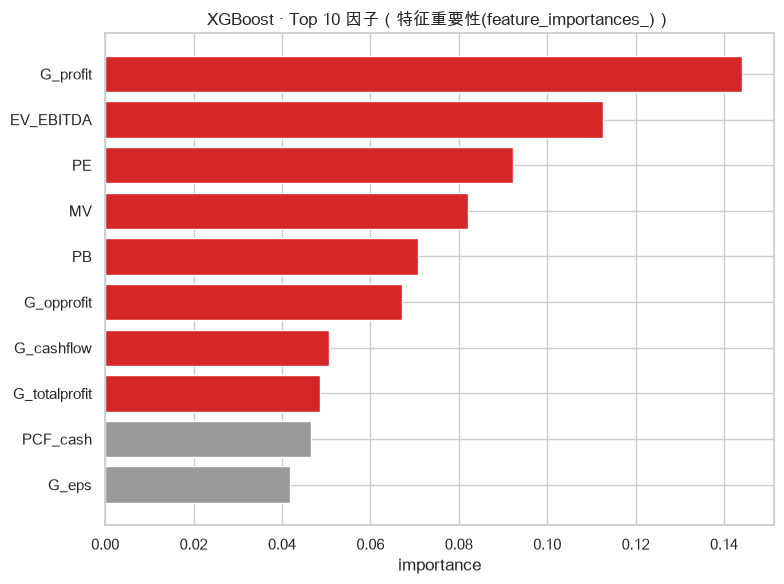

XGBoost 分析视角: 特征重要性(feature_importances_)
最强因子 Top3: ['G_profit', 'EV_EBITDA', 'PE']
最弱因子 Bottom3: ['G_revenue', 'G_assets', 'DIV']


In [33]:

# XGBoost · 分析模块（特征可解释性）
r = results['XGBoost']
m = r['model']
# 优先用模型自带特征重要性/系数，否则用排列重要性（黑盒模型统一视图）
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=FEATURES)
    kind = '特征重要性(feature_importances_)'
elif hasattr(m, 'coef_'):
    imp = pd.Series(m.coef_[0], index=FEATURES).abs()
    kind = '系数绝对值(|coef|)'
else:
    perm = permutation_importance(m, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(perm.importances_mean, index=FEATURES)
    kind = '排列重要性(permutation importance)'
imp = imp.sort_values(ascending=False)
topn = 10
top = imp.head(topn)
plt.figure(figsize=(8, 6))
colors = [COLOR_UP if v > imp.median() else '#999999' for v in top.values[::-1]]
plt.barh(top.index[::-1], top.values[::-1], color=colors)
plt.title('XGBoost · Top {} 因子（{}）'.format(topn, kind))
plt.xlabel('importance'); plt.tight_layout(); plt.show()
print('XGBoost 分析视角:', kind)
print('最强因子 Top3:', list(imp.head(3).index))
print('最弱因子 Bottom3:', list(imp.tail(3).index))


## 第 13 部分 · 量化视角延伸：简易分层回测

模型指标好 ≠ 选股有效。用最优模型输出的**预测概率**给测试期股票打分，在每个报告期内横截面排序，
分 5 组（分位），看**高分组 vs 低分组的实际正例命中率差异**——若单调上升，说明信号有区分力
（类比多空组合的选股有效性，呼应 IC / 单调性思想）。

最优模型（按 AUC）: 随机森林 RF


,命中率,数量
分组,,
Q1低,0.124,853
Q2,0.161,852
Q3,0.198,852
Q4,0.209,852
Q5高,0.254,853


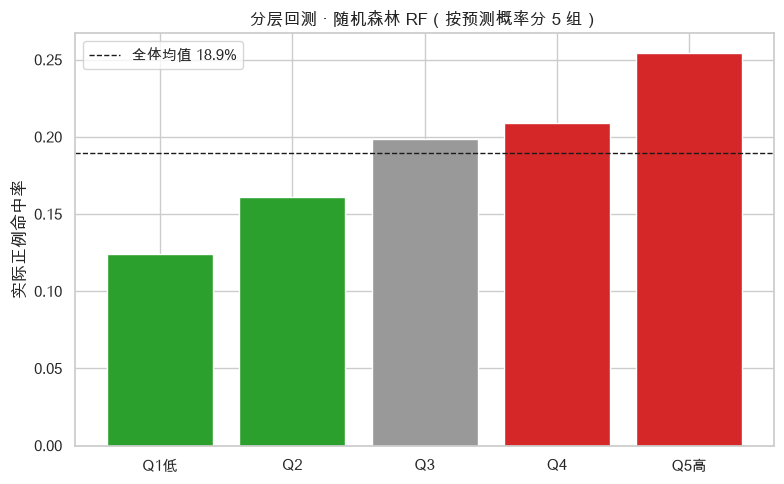

Top组(Q5高)命中率 25.4% vs Bottom组(Q1低) 12.4%
多空区分度(高-低) = 13.0%  ->  越大说明信号单调性 / 选股有效性越强


In [34]:
best_name = cmp.index[0]
best = results[best_name]
print('最优模型（按 AUC）:', best_name)

test_back = test_raw[['Date', 'Code', 'Y']].copy()
test_back['proba'] = best['y_proba']
# 在每个测试报告期内做横截面排序，避免跨期不可比
test_back['pct_rank'] = test_back.groupby('Date')['proba'].rank(pct=True)
test_back['分组'] = pd.qcut(test_back['pct_rank'], 5, labels=['Q1低', 'Q2', 'Q3', 'Q4', 'Q5高'])
grp = test_back.groupby('分组', observed=True)['Y'].agg(命中率='mean', 数量='count')
display(grp.round(3))

plt.figure(figsize=(8, 5))
bar_colors = [COLOR_DOWN, COLOR_DOWN, '#999999', COLOR_UP, COLOR_UP]
plt.bar(grp.index.astype(str), grp['命中率'], color=bar_colors)
plt.axhline(y=y_test.mean(), color='k', ls='--', lw=1, label='全体均值 {:.1%}'.format(y_test.mean()))
plt.ylabel('实际正例命中率')
plt.title('分层回测 · {}（按预测概率分 5 组）'.format(best_name))
plt.legend()
plt.tight_layout()
plt.show()

spread = grp['命中率'].iloc[-1] - grp['命中率'].iloc[0]
print('Top组(Q5高)命中率 {:.1%} vs Bottom组(Q1低) {:.1%}'.format(grp['命中率'].iloc[-1], grp['命中率'].iloc[0]))
print('多空区分度(高-低) = {:.1%}  ->  越大说明信号单调性 / 选股有效性越强'.format(spread))

## 第 14 部分 · 结论与建议

下面代码自动汇总关键结论；解读要点也一并给出。

In [35]:
# 最优模型的特征重要性（结论里展示，避免依赖前面章节的局部变量）
best_m = results[best_name]['model']
if hasattr(best_m, 'feature_importances_'):
    best_imp = pd.Series(best_m.feature_importances_, index=FEATURES)
elif hasattr(best_m, 'coef_'):
    best_imp = pd.Series(best_m.coef_[0], index=FEATURES).abs()
else:
    _p = permutation_importance(best_m, X_test, y_test, n_repeats=5,
                                random_state=RANDOM_STATE, scoring='roc_auc')
    best_imp = pd.Series(_p.importances_mean, index=FEATURES)
top_factors = list(best_imp.sort_values(ascending=False).head(3).index)

print('=' * 64)
print('量化选股 ML 分类模型 · 样例结论（自动汇总）')
print('=' * 64)
print('数据规模       : {} 样本 x {} 因子, {} 只股票 x {} 期'.format(
    len(df), len(FEATURES), df['Code'].nunique(), df['Date'].nunique()))
print('参与对比模型   :', list(results.keys()))
print('XGBoost 是否启用:', 'XGBoost' in results)
print('最优模型(AUC)  : {}  (AUC={:.3f}, F1={:.3f})'.format(best_name, best['auc'], best['f1']))
print('分层多空区分度 : {:.1%}'.format(spread))
print('最优模型最强因子:', top_factors)
print()
print('解读提示:')
print(' 1) AUC>0.6 在 A 股噪声中已算较强信号；若接近 0.5 则模型近乎随机。')
print(' 2) 优先看 AUC / 分层单调性，而非 Accuracy（正例仅约 40%）。')
print(' 3) 模型指标好 != 策略赚钱，实盘需扣交易成本、做 Walk-Forward、防未来函数。')
print('=' * 64)

量化选股 ML 分类模型 · 样例结论（自动汇总）
数据规模       : 20772 样本 x 17 因子, 4281 只股票 x 5 期
参与对比模型   : ['逻辑回归 LR', '决策树 DT', '随机森林 RF', 'K近邻 KNN', '支持向量机 SVM', '朴素贝叶斯 NB', 'XGBoost']
XGBoost 是否启用: True
最优模型(AUC)  : 随机森林 RF  (AUC=0.585, F1=0.318)
分层多空区分度 : 13.0%
最优模型最强因子: ['EV_EBITDA', 'G_profit', 'PE']

解读提示:
 1) AUC>0.6 在 A 股噪声中已算较强信号；若接近 0.5 则模型近乎随机。
 2) 优先看 AUC / 分层单调性，而非 Accuracy（正例仅约 40%）。
 3) 模型指标好 != 策略赚钱，实盘需扣交易成本、做 Walk-Forward、防未来函数。


### 局限与改进方向

- **数据偏短**：仅 5 个季度报告期，样本外测试只有 1 期。建议做 **Walk-Forward（滚动窗口）回测**，更稳健地评估稳定性。
- **中性化缺失**：当前未做行业 / 市值中性化，因子可能混入市值或行业暴露。可在预处理阶段加入「对市值 / 行业做横截面回归取残差」。
- **成本视角缺失**：分层回测未扣交易成本、未考虑换手率与冲击成本。实盘需叠加**换手率约束**与**费率**。
- **阈值敏感**：默认 0.5 阈值未必最优，可结合业务目标（怕 FP 还是怕 FN）调阈值，或用**精确率-召回率权衡**选点。
- **共线性**：PE 与 PE_ex 等强共线，LR 系数解读需谨慎；可用正则（L1/L2）或做因子筛选。
- **未来函数风险**：务必确认 Y 标签是用**未来一期**真实收益构建，且特征仅用**当期及以前**信息。

> 📌 配合阅读：本工作坊另两份手册《机器学习算法分类详解》《机器学习模型评价指标详解（量化版）》，
> 分别对应「算法原理」与「指标解读」，与本文 notebook 形成「原理 → 指标 → 实战」闭环。